In [1]:
import pandas as pd

df = pd.read_csv("sales_data.csv")
df.head()

,Date,Revenue,Marketing_Spend
0,2022-01,12000,2000
1,2022-02,13500,2200
2,2022-03,12800,2100
3,2022-04,15000,2500
4,2022-05,6000,2700


In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['Time'] = range(len(df))  # variable de tendencia

In [3]:
from sklearn.linear_model import LinearRegression

X = df[['Time', 'Marketing_Spend']]
y = df['Revenue']

model = LinearRegression()
model.fit(X, y)

df['Predicted_Revenue'] = model.predict(X)
df.head()

,Date,Revenue,Marketing_Spend,Time,Predicted_Revenue
0,2022-01-01,12000,2000,0,10568.201829
1,2022-02-01,13500,2200,1,11540.783384
2,2022-03-01,12800,2100,2,12155.076758
3,2022-04-01,15000,2500,3,13366.517101
4,2022-05-01,6000,2700,4,14339.098657


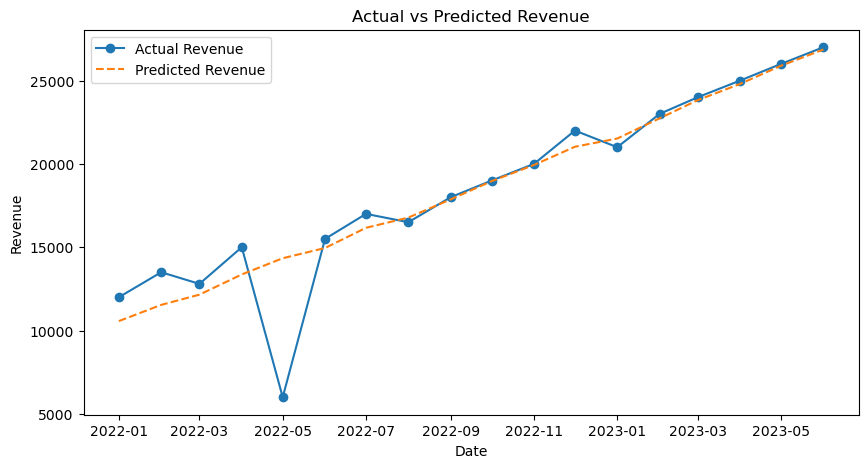

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Revenue'], label='Actual Revenue', marker='o')
plt.plot(df['Date'], df['Predicted_Revenue'], label='Predicted Revenue', linestyle='--')
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [6]:
import numpy as np

future_time = np.arange(len(df), len(df) + 6)
future_marketing = [5500, 5700, 6000, 6200, 6500, 7000]  # ejemplo

future_df = pd.DataFrame({
    'Time': future_time,
    'Marketing_Spend': future_marketing
})

future_df['Predicted_Revenue'] = model.predict(future_df)
future_df

,Time,Marketing_Spend,Predicted_Revenue
0,18,5500,27955.240433
1,19,5700,28927.821989
2,20,6000,30019.832938
3,21,6200,30992.414494
4,22,6500,32084.425443
5,23,7000,33415.295180


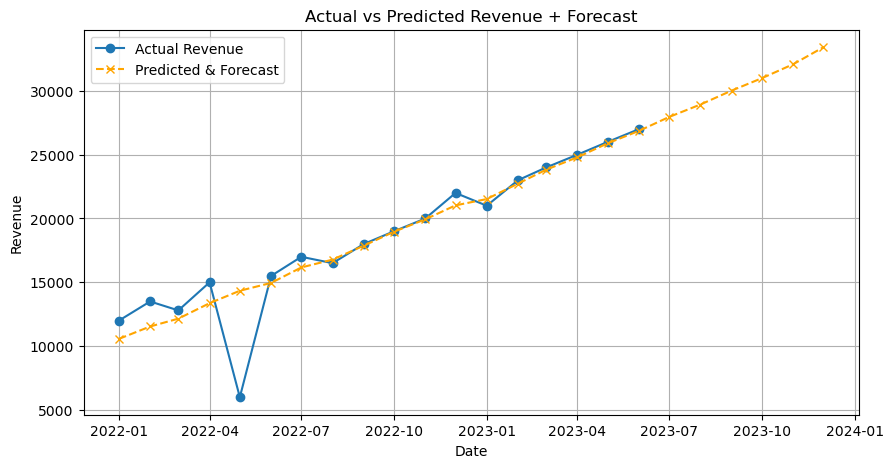

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Combinar histórico y futuro para la gráfica
all_dates = pd.date_range(start=df['Date'].iloc[0], periods=len(df)+len(future_df), freq='MS')
all_pred = pd.concat([df['Predicted_Revenue'], future_df['Predicted_Revenue']], ignore_index=True)

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Revenue'], marker='o', label='Actual Revenue')
plt.plot(all_dates, all_pred, marker='x', linestyle='--', color='orange', label='Predicted & Forecast')
plt.title("Actual vs Predicted Revenue + Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

## Executive Insights & Recommendations

### Revenue Forecast Overview 📈
- Predicted revenue for the next 6 months grows from **27,955 → 33,415**, representing ~20% increase.
- Marketing spend is strongly correlated with revenue: higher investment drives higher sales.
- Overall trend is positive, but occasional dips indicate other external factors might influence revenue.

### Key Insights
1. **Consistent growth trend**: Revenue steadily increases month-over-month.
2. **Marketing effectiveness**: Months with higher marketing spend result in higher revenue.
3. **Seasonal fluctuations**: Some months (e.g., May 2022) show temporary drops, suggesting other variables at play.

### Recommendations for Business Action
- **Optimize marketing budget**: Allocate funds to months where marketing ROI is historically higher.
- **Track forecast vs actual**: Monitor monthly performance to adjust campaigns in real time.
- **Investigate anomalies**: Identify and mitigate factors causing temporary revenue dips.
- **Plan for growth**: Use predicted revenue trends to set realistic sales targets and KPI goals.